# PPE Detection — Retrain (augmentasi + imgsz 1280)

Latih ulang **YOLO11s** untuk menaikkan akurasi kelas **shoes** (objek kecil) tanpa menambah data.

Versi **lokal (GPU sendiri)** — baca `../dataset/` langsung, hasil otomatis disalin ke `../app/best.pt`.

Jalankan notebook ini dari folder `training/`.

## 0. Cek environment + GPU

In [1]:
# PENTING (Anaconda): cegah crash konflik OpenMP saat matplotlib plot.
# Harus diset SEBELUM import torch/numpy/matplotlib. Restart kernel dulu!
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# kalau ultralytics belum ada: hapus komentar baris bawah
# %pip install -q ultralytics
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (lambat!)')
assert torch.cuda.is_available(), 'GPU tidak terdeteksi — install torch versi CUDA dulu'

CUDA available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Path dataset
Tulis `data.yaml` dengan path absolut (urutan kelas: 0 helmet, 1 shoes, 2 vest).

In [2]:
import os, glob

HERE = os.getcwd()
DATASET = os.path.abspath(os.path.join(HERE, '..', 'dataset'))
print('Dataset:', DATASET)
assert os.path.isdir(os.path.join(DATASET, 'train', 'images')), 'dataset/train/images tidak ada'

yaml_text = f"""path: {DATASET}
train: train/images
val: valid/images
test: test/images
nc: 3
names: [helmet, shoes, vest]
"""
DATA = os.path.join(HERE, 'data.yaml')
with open(DATA, 'w') as f:
    f.write(yaml_text)
print(yaml_text)

for s in ['train', 'valid', 'test']:
    n = len(glob.glob(os.path.join(DATASET, s, 'images', '*')))
    print(f'{s}: {n} citra')

Dataset: c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset
path: c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset
train: train/images
val: valid/images
test: test/images
nc: 3
names: [helmet, shoes, vest]

train: 369 citra
valid: 15 citra
test: 16 citra


## 2. Training (augmentasi agresif)
**RTX 3050 4GB** → `imgsz=1024, batch=4`. Kalau **OOM** (CUDA out of memory): turunkan `batch` ke 2, atau `imgsz` ke 896 / 768. Lebih besar = shoes lebih bagus, tapi VRAM 4GB terbatas.

In [3]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

model.train(
    data=DATA,
    epochs=150,
    imgsz=1024,        # resolusi tinggi -> objek kecil (shoes) lebih jelas; 4GB tahan ~1024
    batch=4,           # OOM -> turunkan ke 2
    name='ppe_aug',
    patience=40,
    seed=0,
    cache=False,       # hemat RAM/VRAM
    workers=0,         # WAJIB 0 di Windows+Jupyter (workers>0 -> kernel crash)
    # ---- augmentasi ----
    mosaic=1.0,
    close_mosaic=15,
    copy_paste=0.3,    # duplikat instance -> bantu kelas jarang/kecil
    mixup=0.15,
    scale=0.9,
    fliplr=0.5,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
)

Ultralytics 8.4.68  Python-3.13.5 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\training\data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_aug, nbs=64, nms=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000013AC8C1DD30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

## 3. Grafik hasil training

Run dir: runs\detect\ppe_aug

results.png


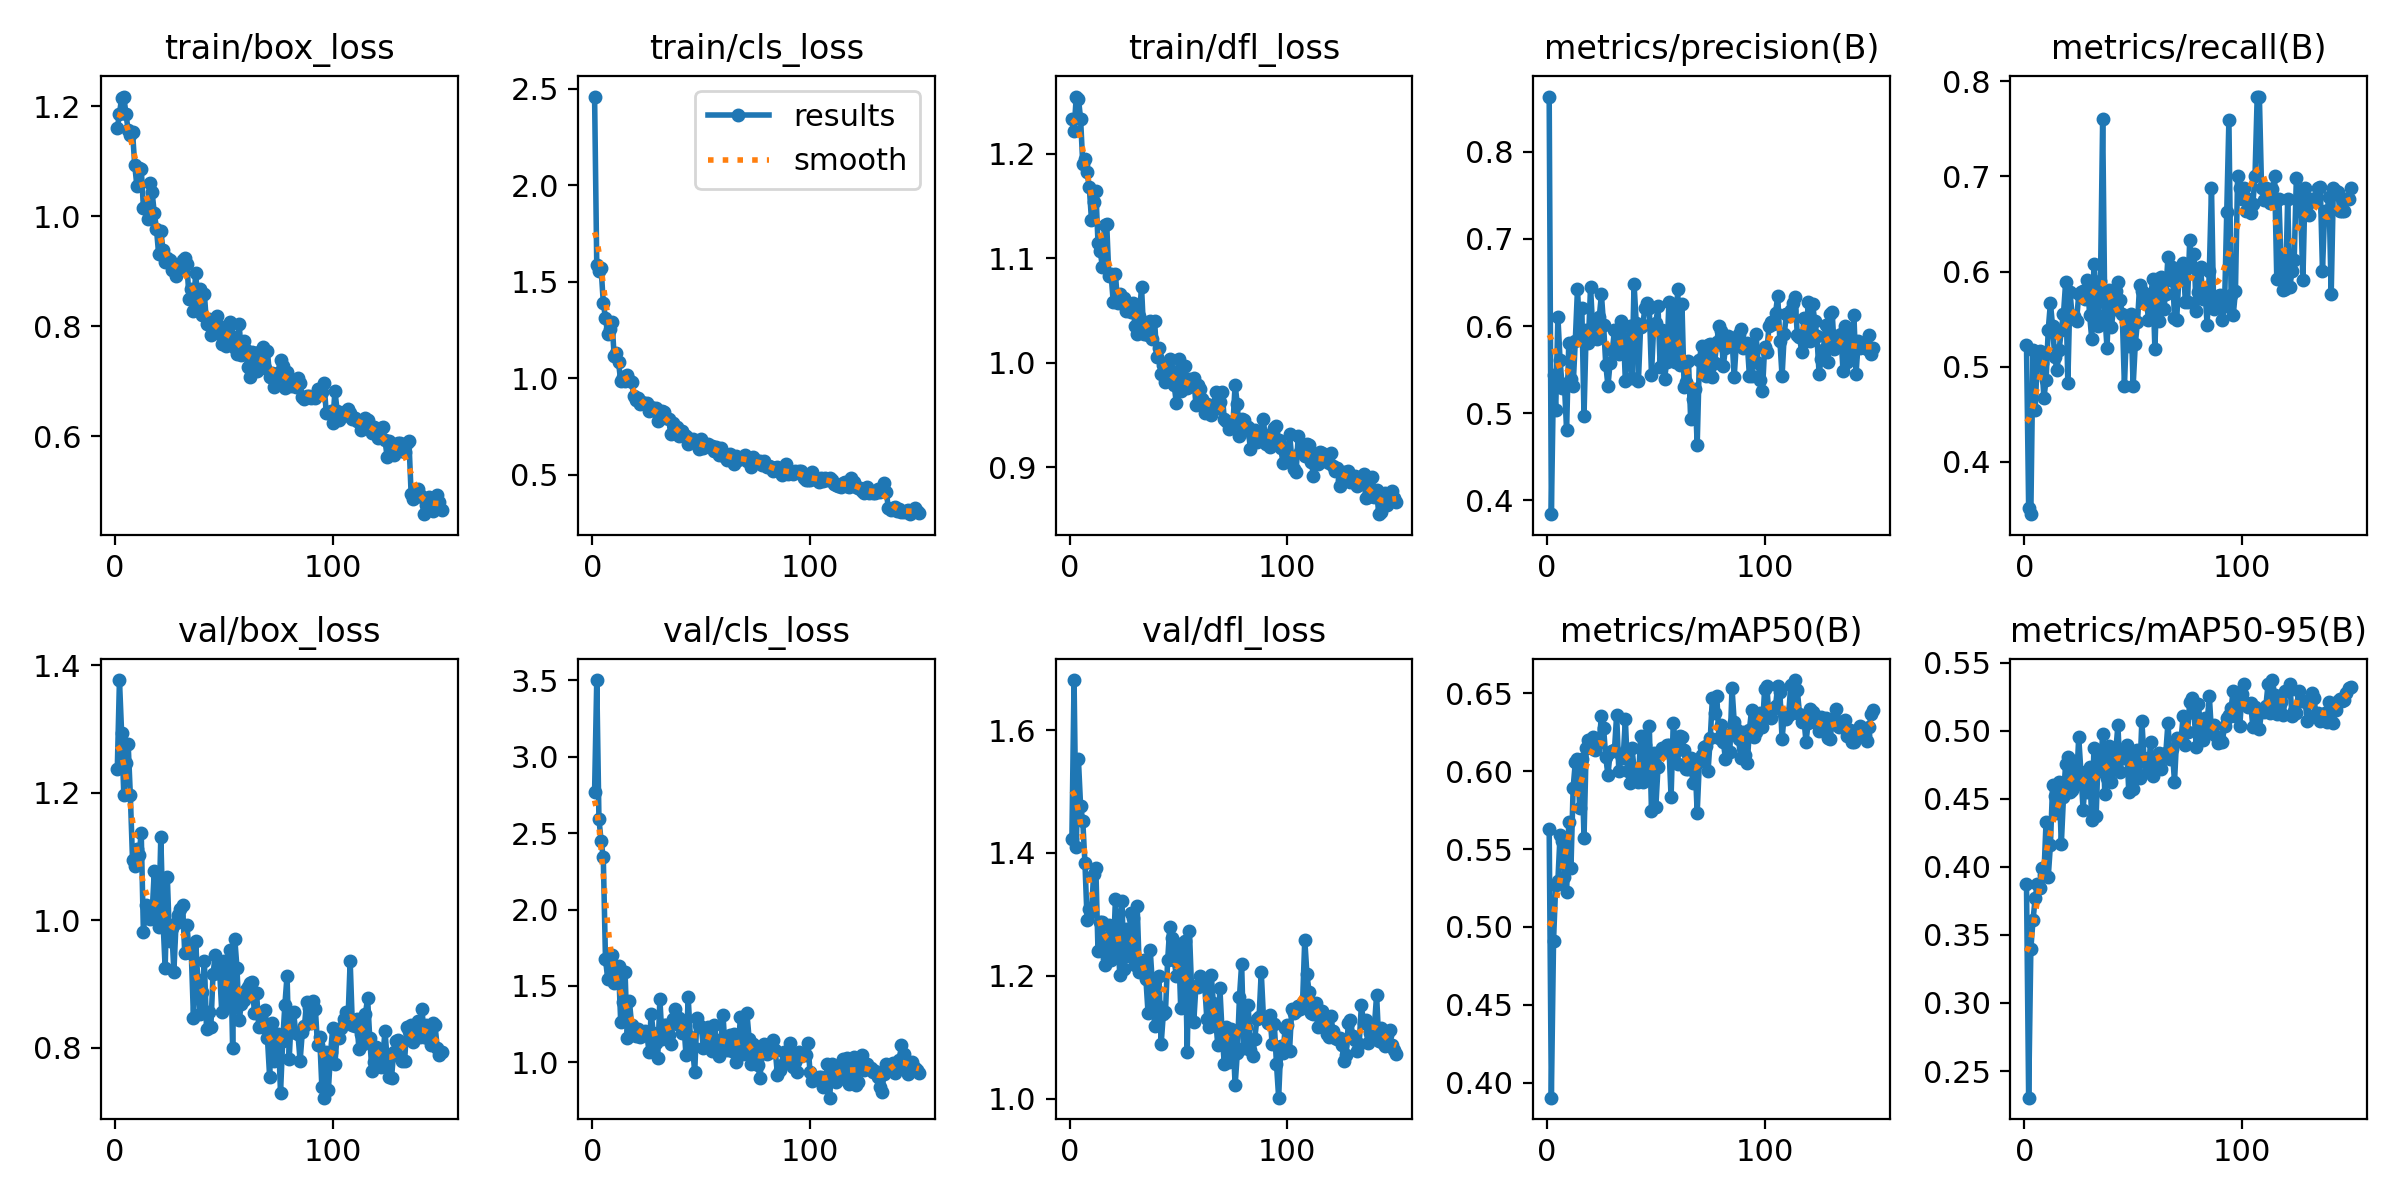


confusion_matrix_normalized.png


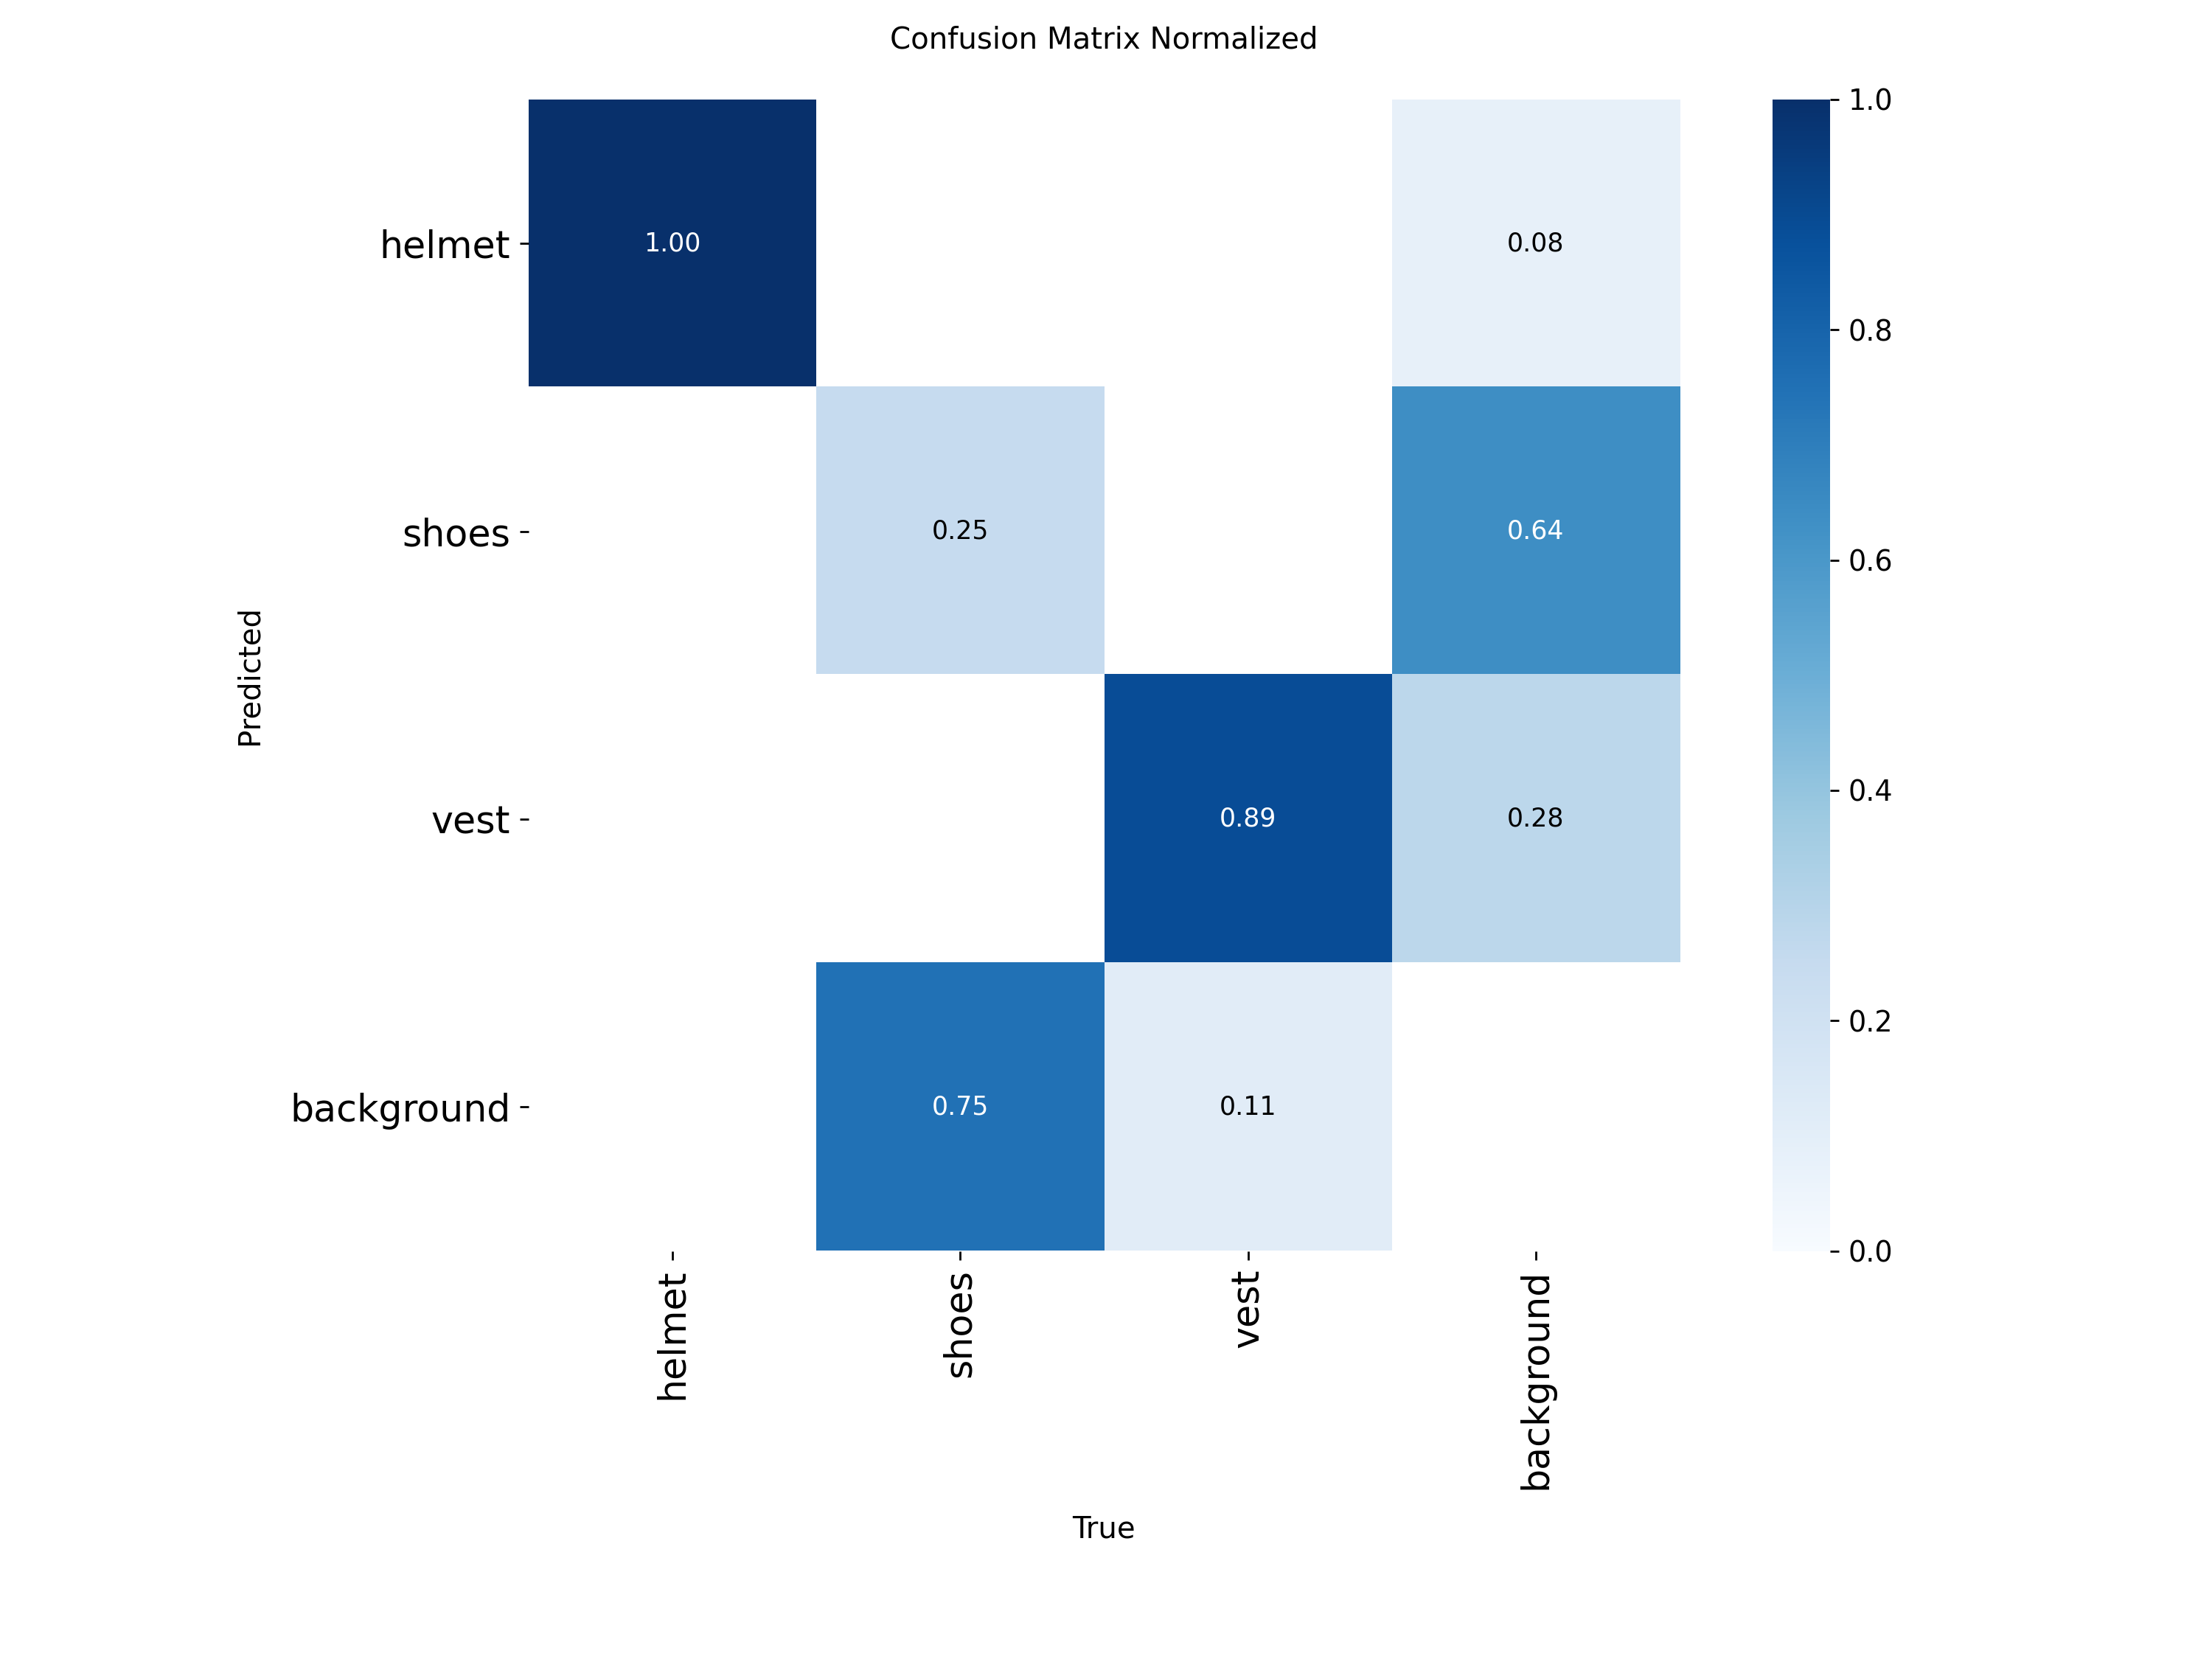


BoxPR_curve.png


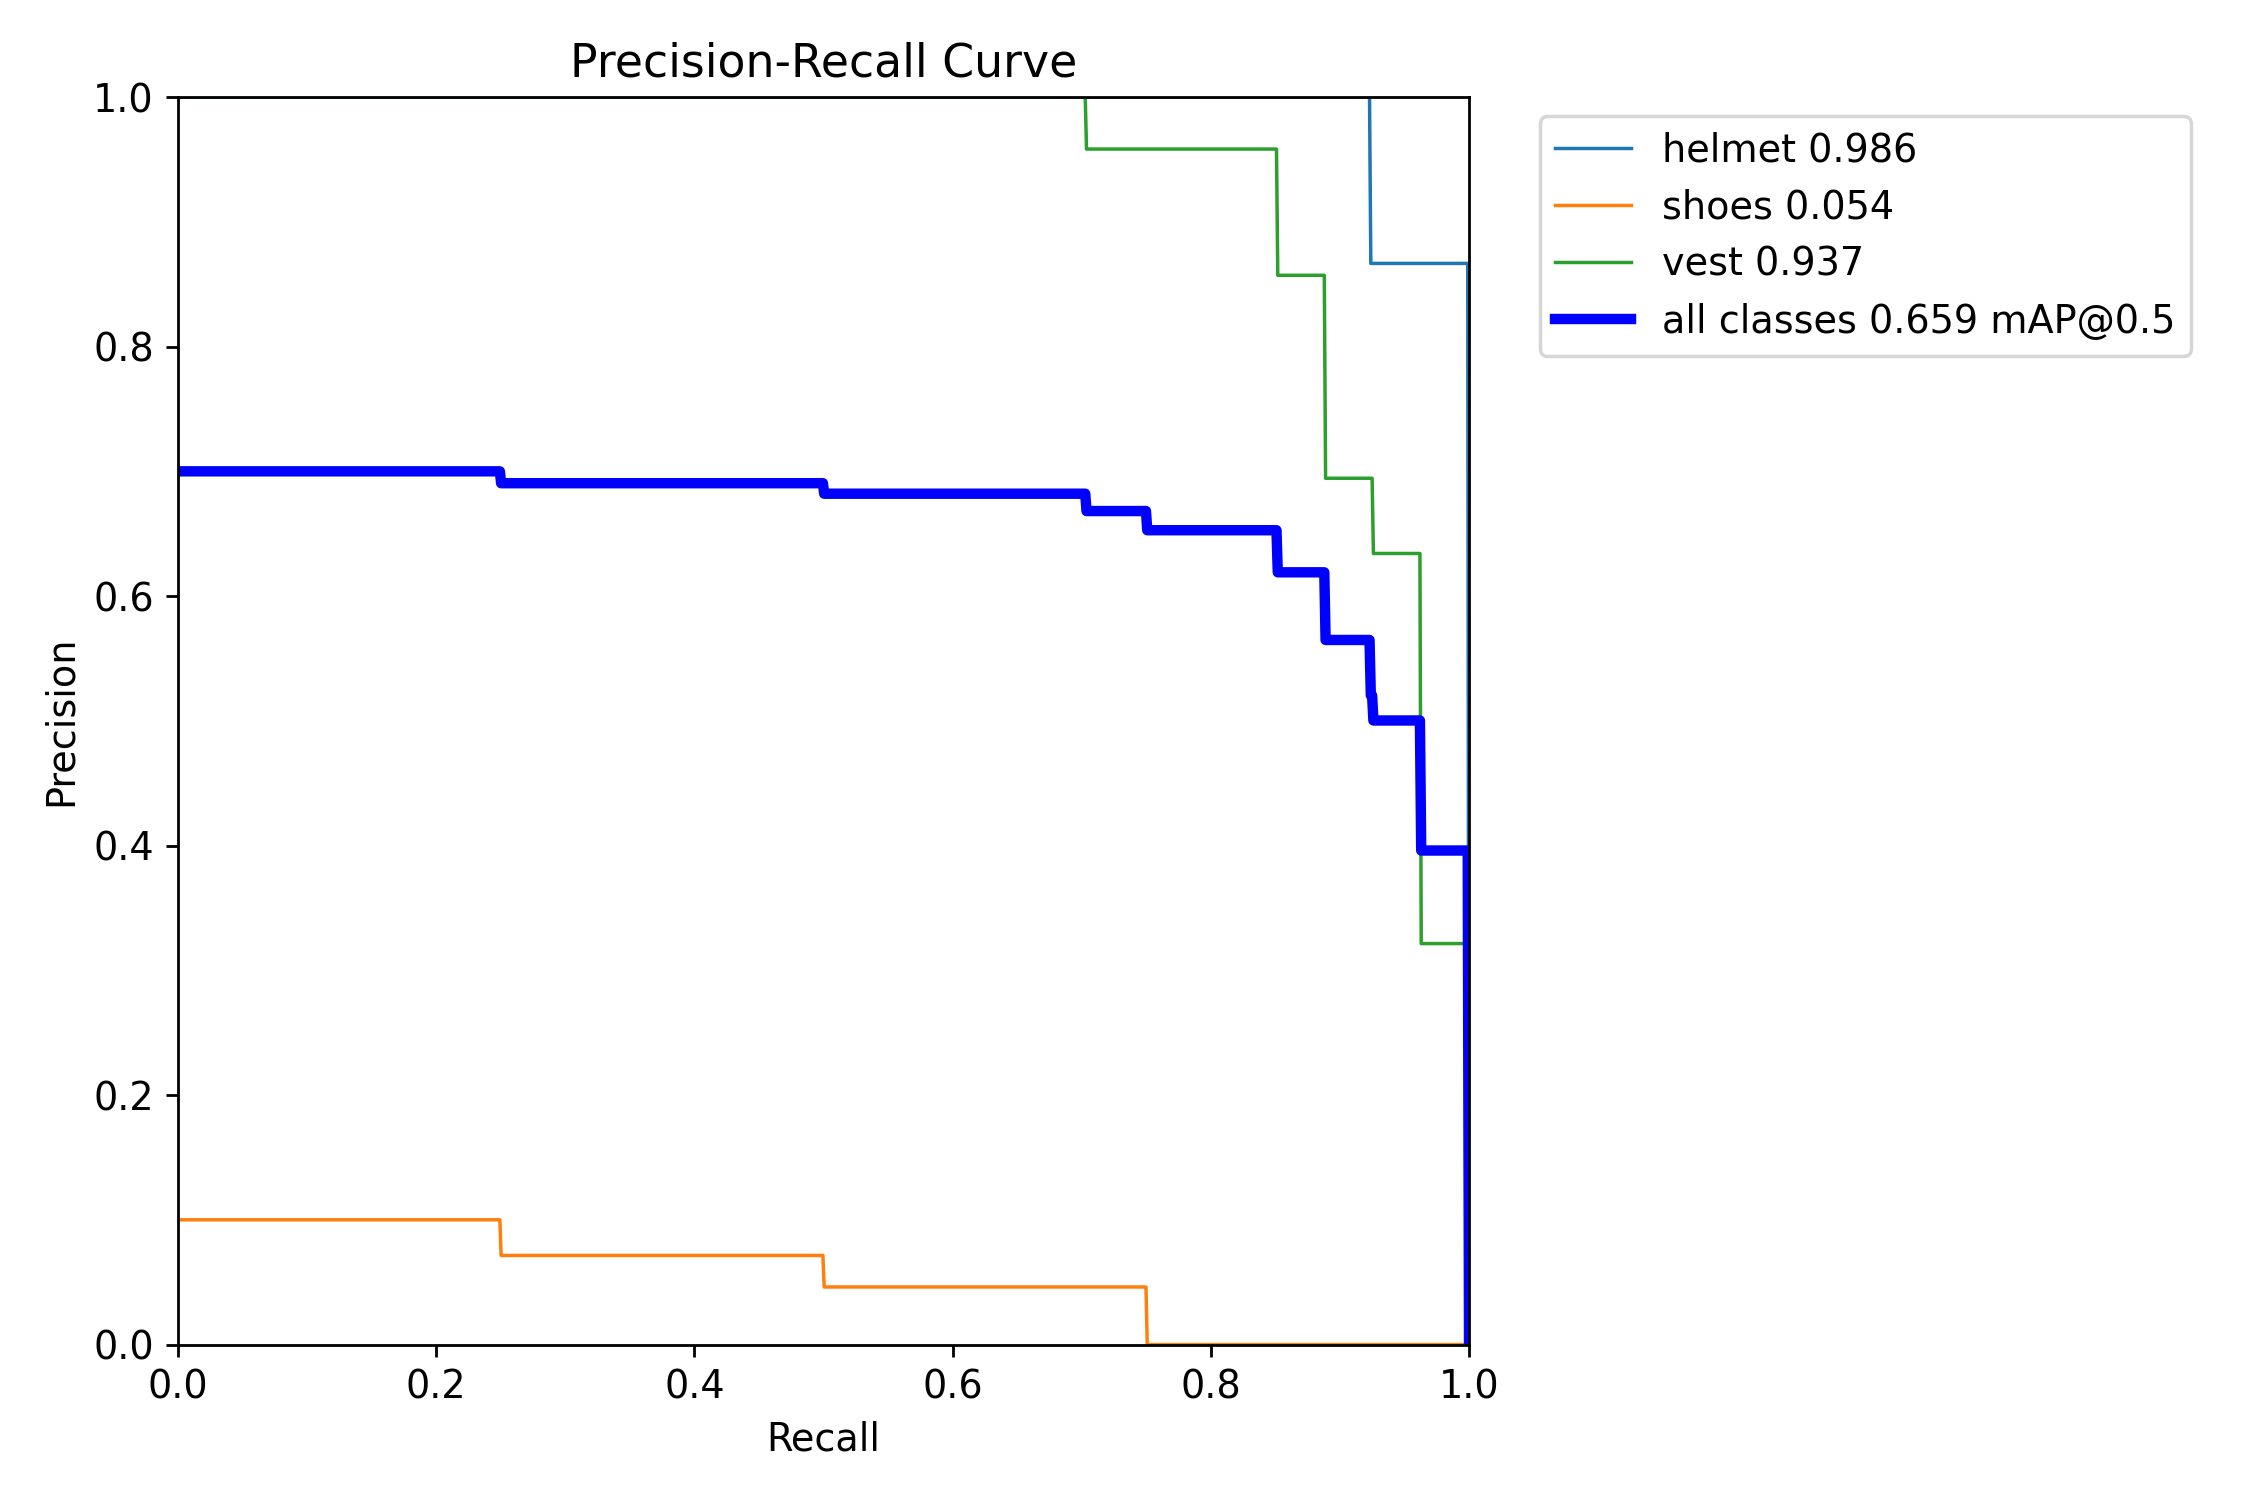


BoxF1_curve.png


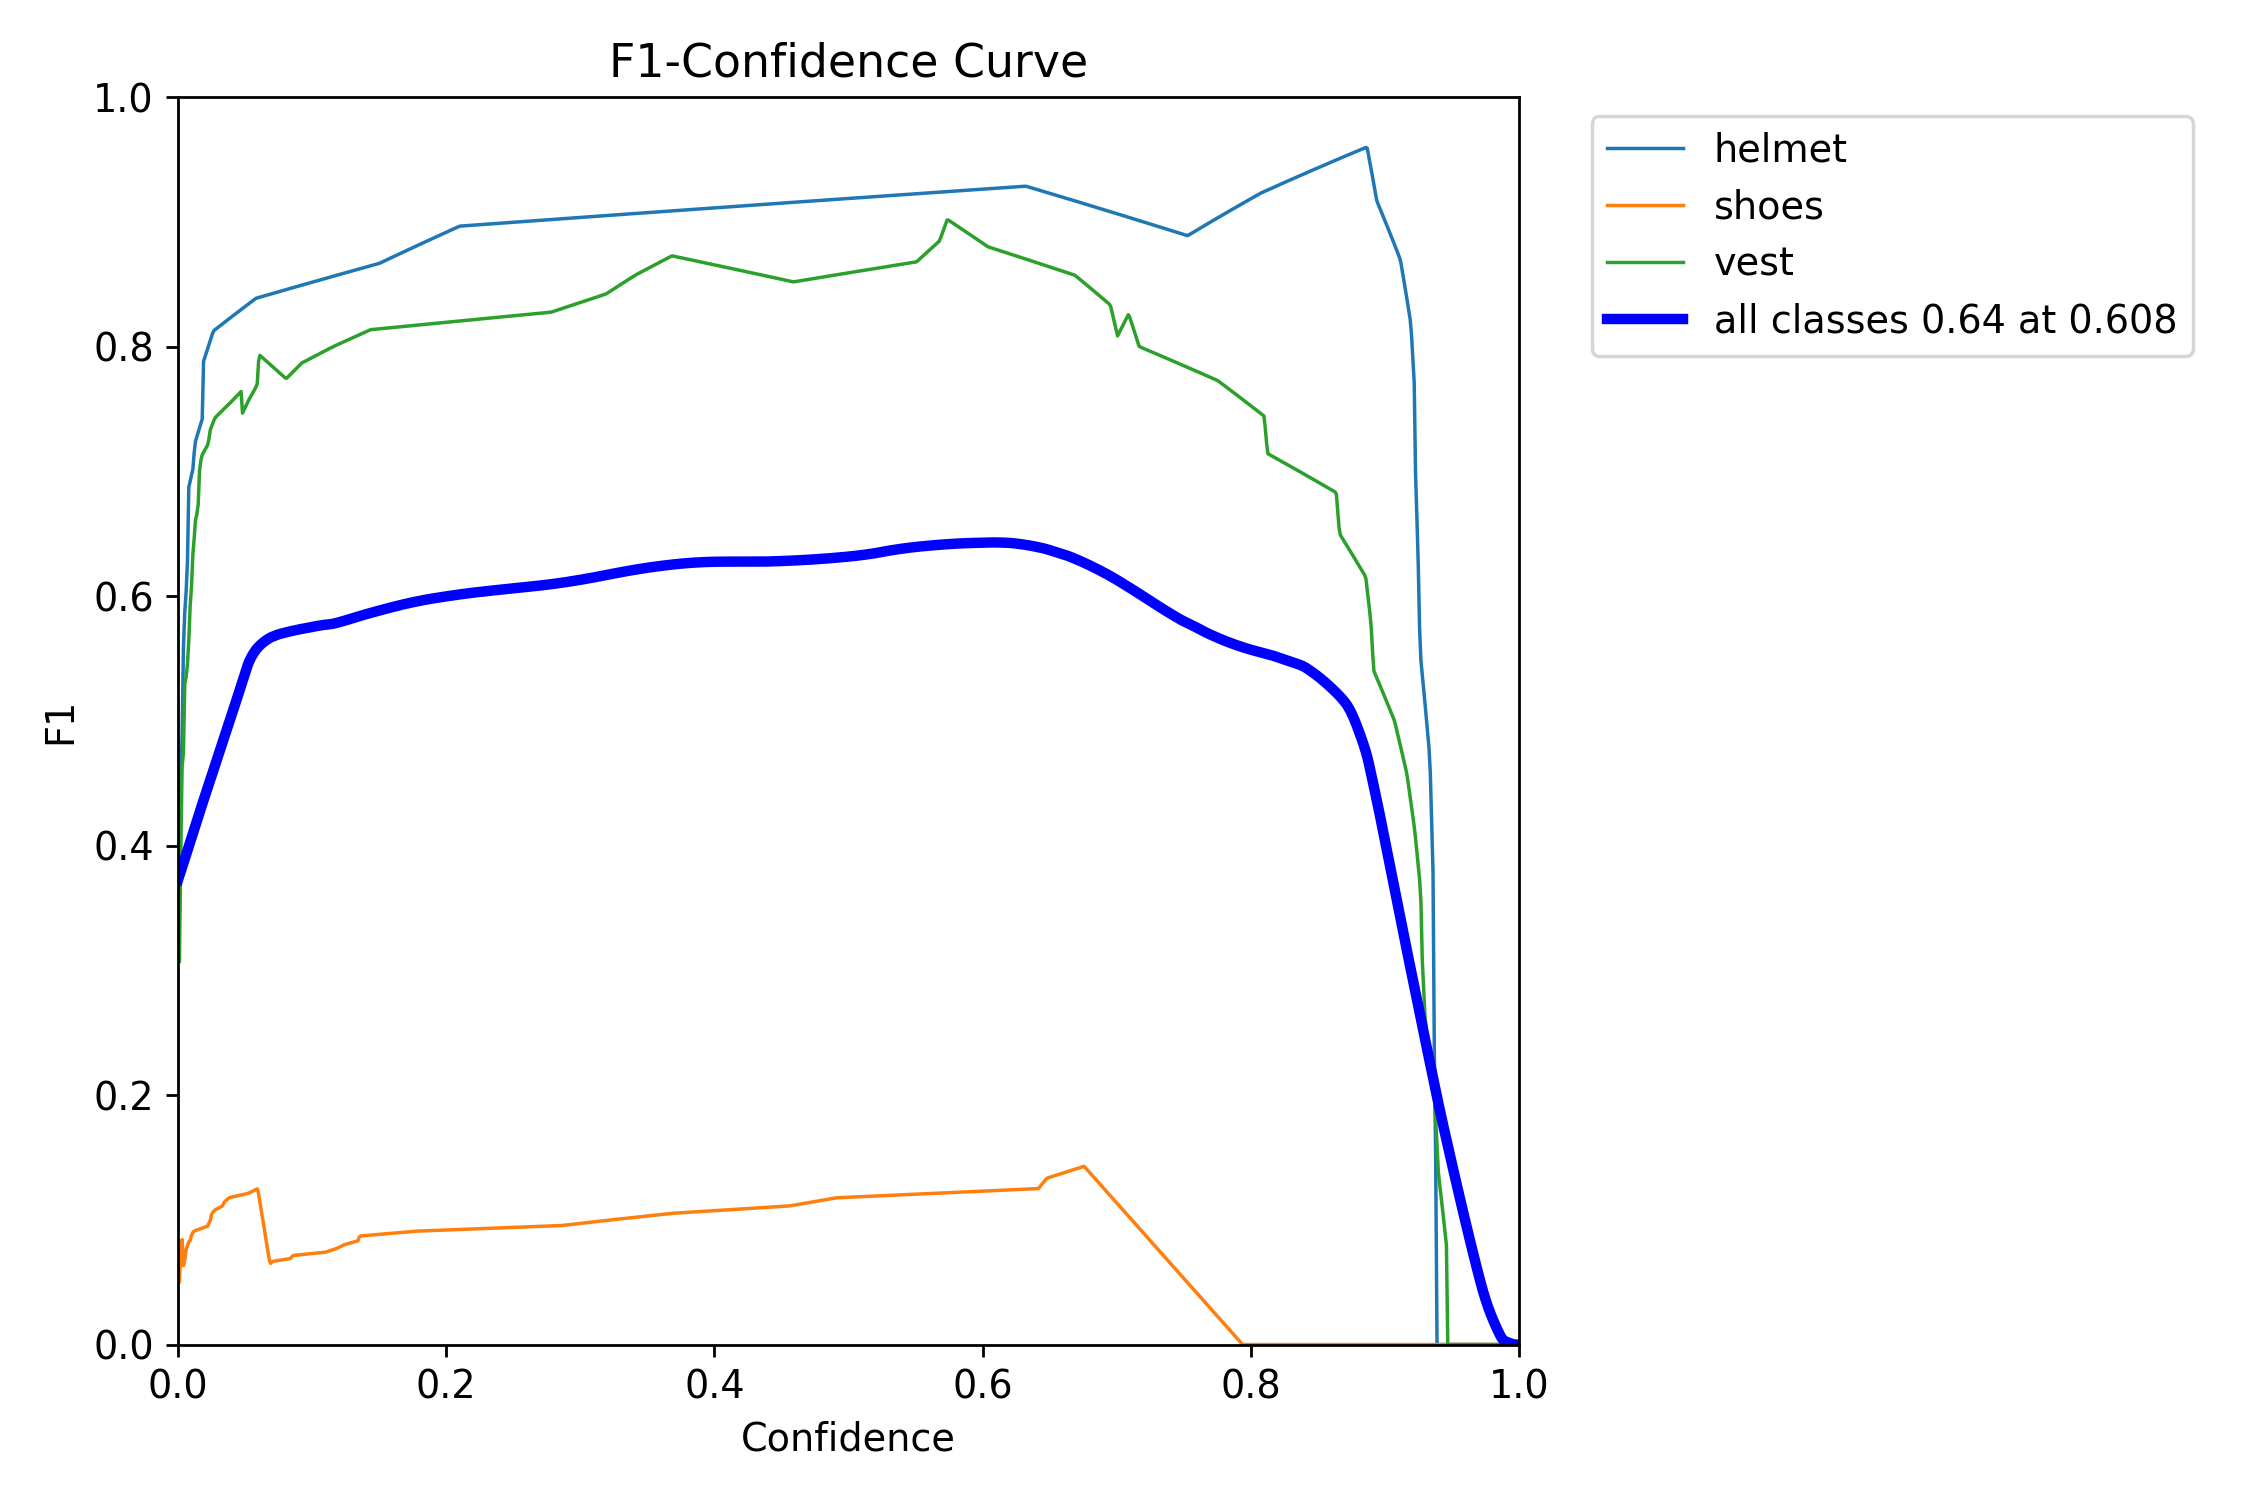

In [4]:
from IPython.display import Image, display

run_dir = sorted(glob.glob(os.path.join('runs', 'detect', 'ppe_aug*')))[-1]
print('Run dir:', run_dir)

for fname in ['results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'BoxF1_curve.png']:
    p = os.path.join(run_dir, fname)
    if os.path.exists(p):
        print('\n' + fname)
        display(Image(p))

## 4. Evaluasi — mAP per kelas
**Lihat baris `shoes`** untuk memutuskan: keep 3 kelas atau drop shoes.

In [6]:
metrics = model.val(data=DATA, imgsz=1024)
print('=== RINGKASAN ===')
print('Precision   :', round(float(metrics.box.mp), 3))
print('Recall      :', round(float(metrics.box.mr), 3))
print('mAP@0.5     :', round(float(metrics.box.map50), 3))
print('mAP@0.5:0.95:', round(float(metrics.box.map), 3))
print('--- per kelas (mAP@0.5) ---')
for i, name in model.names.items():
    print(f'  {name:8s} = {metrics.box.maps[i]:.3f}')

Ultralytics 8.4.68  Python-3.13.5 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 164.858.1 MB/s, size: 56.3 KB)
val: Scanning C:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset\valid\labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 2.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 0% ──────────── 0/1  5.0s


RuntimeError: DataLoader worker (pid(s) 7204, 14592) exited unexpectedly

## 5. Contoh prediksi (validation batch)

In [ ]:
for f in sorted(glob.glob(os.path.join(run_dir, 'val_batch*_pred.jpg')))[:2]:
    display(Image(f))

## 6. Salin model terbaik ke aplikasi
Backup `app/best.pt` lama, lalu ganti dengan hasil baru.

In [ ]:
import shutil

best = os.path.join(run_dir, 'weights', 'best.pt')
app_model = os.path.abspath(os.path.join(HERE, '..', 'app', 'best.pt'))
print('best.pt baru:', best, '|', round(os.path.getsize(best)/1e6, 1), 'MB')

# backup model lama dulu
if os.path.exists(app_model):
    shutil.copy(app_model, app_model + '.bak')
    print('Backup lama ->', app_model + '.bak')

shutil.copy(best, app_model)
print('Disalin ke ->', app_model)

---
### Keputusan
- **shoes mAP@0.5 naik (> 0.4)** → keep 3 kelas, `app/best.pt` sudah terganti.
- **masih jeblok (< 0.2)** → drop kelas shoes (pakai helmet + vest saja, mAP efektif ~0.95). Restore backup: `app/best.pt.bak`.